<a href="https://colab.research.google.com/github/eko-andri-prasetyo/Deep-Learning-Tingkat-Mahir/blob/main/Submission_Akhir_DLTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Akhir DLTM – Multivariate Multi-Horizon Time Series Forecasting (Bitcoin)
Nama: **Syaikh Eko**

Target: memprediksi **Close** untuk **24 jam ke depan** (multi-step).

## 0. Setup
Jika menjalankan di Colab dan butuh install package tambahan, jalankan cell ini (boleh skip bila sudah ada).

In [36]:
# (Opsional) Install dependencies
# !pip -q install -r requirements.txt


## 1. Load Data
Notebook ini bisa membaca dataset dari:
- file lokal `Bitcoin3.csv` (bila ada di folder yang sama), atau
- URL Google Drive (sesuai instruksi Dicoding).

In [37]:
import os
import numpy as np
import pandas as pd

# Pilih sumber data: lokal atau URL
LOCAL_CSV = "Bitcoin3.csv"

csv_url = "https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr"

if os.path.exists(LOCAL_CSV):
    df = pd.read_csv(LOCAL_CSV)
else:
    df = pd.read_csv(csv_url)

# Jika yang terunduh adalah full dataset multi-coin, filter ke Bitcoin (jika kolomnya ada)
# Beberapa versi dataset punya kolom seperti 'symbol' / 'Coin' / 'Name'.
# Kalau dataset sudah khusus Bitcoin (seperti file Bitcoin3.csv), bagian ini tidak mengubah apa pun.
for col in ["symbol", "Symbol", "coin", "Coin", "name", "Name"]:
    if col in df.columns:
        # contoh filter umum: BTC atau Bitcoin
        df = df[df[col].astype(str).str.contains("BTC|Bitcoin", case=False, na=False)].copy()
        break

# Pastikan kolom Date ada
if "Date" not in df.columns:
    raise ValueError("Kolom 'Date' tidak ditemukan. Periksa struktur dataset yang kamu pakai.")

# FIX: Date format campur (dengan & tanpa microseconds)
df["Date"] = pd.to_datetime(df["Date"], format="mixed", errors="coerce")
df = df.dropna(subset=["Date"]).reset_index(drop=True)

df = df.sort_values("Date").reset_index(drop=True)
df.head()


,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


## 2. Pilih fitur & target (min 3 fitur)
Default menggunakan 6 fitur: `Close`, `Volume USDT`, `RSI`, `MACD_Hist`, `ATR`, `KAMAO`.
Silakan sesuaikan bila kolom berbeda (asalkan input >= 3 fitur).

In [38]:
# Pastikan kolom-kolom ini ada pada dataset yang digunakan
candidate_features = ["Close", "Volume USDT", "RSI", "MACD_Hist", "ATR", "KAMAO"]

missing = [c for c in candidate_features if c not in df.columns]
if missing:
    raise ValueError(f"Kolom fitur tidak ditemukan: {missing}. Sesuaikan list candidate_features dengan kolom dataset kamu.")

features = candidate_features[:]  # >= 3 fitur ✅
target = "Close"

df[features].describe().T


,count,mean,std,min,25%,50%,75%,max
Close,53150.0,2.059536e+04,1.582230e+04,3172.050000,7.976915e+03,1.387810e+04,2.964672e+04,6.863369e+04
Volume USDT,53150.0,6.919215e+07,1.059041e+08,0.000000,1.012558e+07,2.766119e+07,8.944278e+07,3.005634e+09
RSI,53150.0,5.040360e+01,3.210682e+00,35.178834,4.829420e+01,5.003848e+01,5.240627e+01,6.465711e+01
MACD_Hist,53150.0,5.282720e-01,3.532932e+02,-1885.690630,-1.156016e+02,1.015442e+01,1.223675e+02,1.430406e+03
ATR,53150.0,2.217333e+02,2.084014e+02,17.436266,7.270249e+01,1.287876e+02,3.256168e+02,1.004531e+03
KAMAO,53150.0,2.297622e-01,5.168655e+00,-31.767152,-2.717470e+00,-3.274670e-02,3.162442e+00,3.974030e+01


## 3. EDA: Correlation Heatmap (Train only)
Heatmap dihitung pada data train untuk menghindari kebiasaan melihat keseluruhan data.

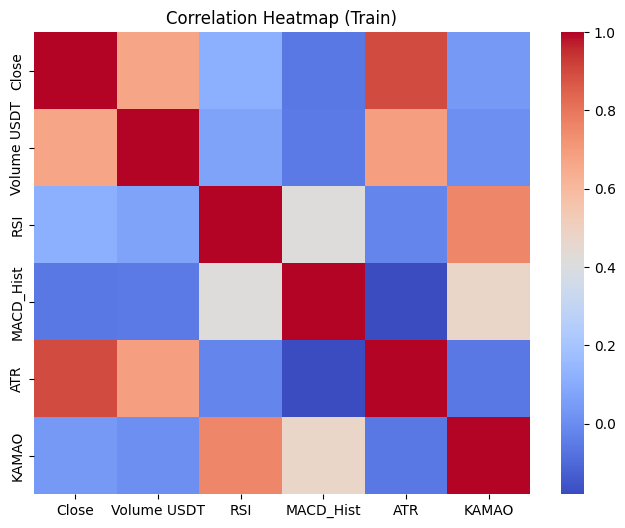

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# split time-series
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

corr = train_df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Train)")
plt.show()


## 4. (Advanced) Dekomposisi data target
Menggunakan `seasonal_decompose` untuk melihat tren/seasonal/residual.

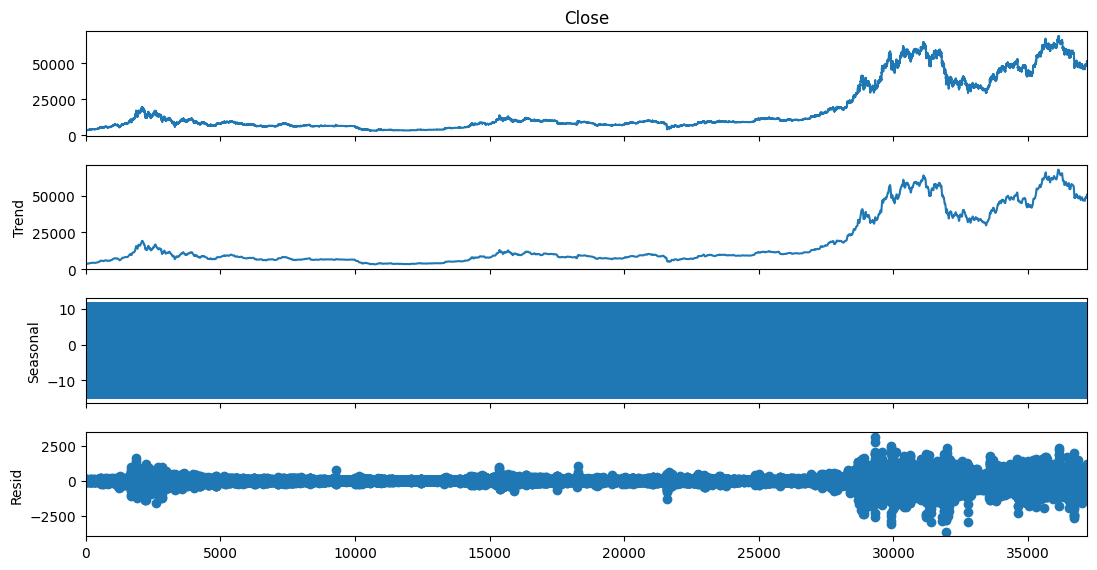

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Banyak data hourly -> period 24 untuk pola harian (opsional)
close_series = train_df[target].astype(float).reset_index(drop=True)
result = seasonal_decompose(close_series, model="additive", period=24)

fig = result.plot()
fig.set_size_inches(12, 6)
plt.show()


## 5. (Advanced) ACF & PACF untuk menentukan WINDOW
Gunakan ACF/PACF untuk justifikasi window size (lookback).

<Figure size 1200x300 with 0 Axes>

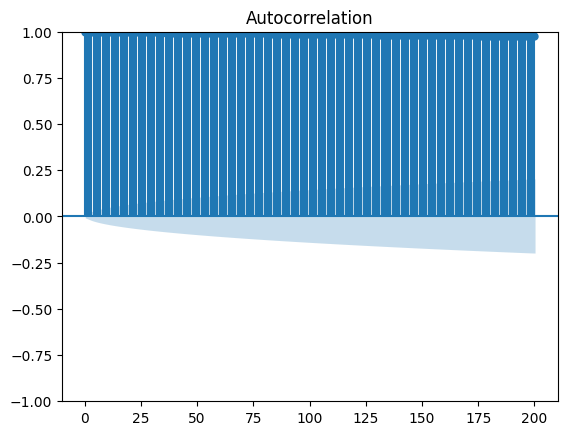

<Figure size 1200x300 with 0 Axes>

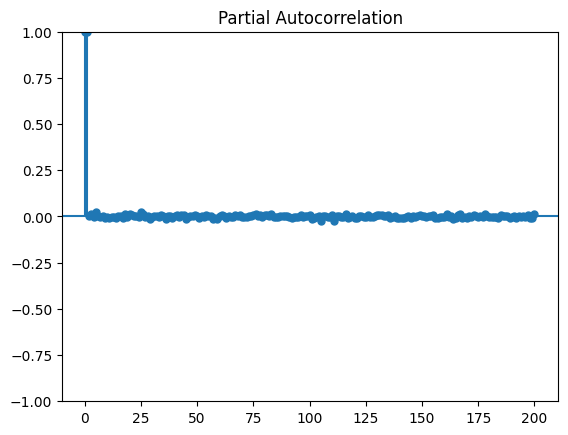

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 3))
plot_acf(close_series, lags=200)
plt.show()

plt.figure(figsize=(12, 3))
plot_pacf(close_series, lags=200, method="ywm")
plt.show()


## 6. Feature Engineering Rolling Statistic (Advanced)
Tambahkan minimal 1 fitur rolling. Contoh: rolling mean & std 24 jam.

In [42]:
df_fe = df.copy()

df_fe["Close_rollmean_24"] = df_fe["Close"].rolling(24).mean()
df_fe["Close_rollstd_24"]  = df_fe["Close"].rolling(24).std()

df_fe = df_fe.dropna().reset_index(drop=True)

# Update split setelah dropna
n = len(df_fe)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df_fe.iloc[:train_end].copy()
val_df   = df_fe.iloc[train_end:val_end].copy()
test_df  = df_fe.iloc[val_end:].copy()

# Tambah rolling features ke list fitur
features_fe = features + ["Close_rollmean_24", "Close_rollstd_24"]

train_df[features_fe].head()


,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,Close_rollmean_24,Close_rollstd_24
0,3647.70,98670.562044,48.507646,-49.453354,86.625836,0.015093,3709.506667,91.112560
1,3606.95,107162.792190,48.366751,-49.745629,86.528735,-0.453320,3698.962917,87.510496
2,3572.85,150926.427424,48.249126,-50.150669,86.412221,-0.843745,3686.520000,83.030244
3,3539.97,190043.740129,48.135914,-50.661754,86.392482,-1.217532,3672.979167,79.071138
4,3592.12,127074.058322,48.328786,-50.963345,86.373427,-0.610674,3661.897500,70.133487


## 7. Scaling tanpa data leakage (fit di train saja)
Pakai scaler terpisah per kolom agar inverse transform target **Close** akurat.

In [43]:
from sklearn.preprocessing import StandardScaler

HORIZON = 24

# Tentukan WINDOW berdasarkan ACF/PACF (contoh default 72 jam)
WINDOW = 72

scalers = {c: StandardScaler() for c in features_fe}

def fit_transform_split(train_df, val_df, test_df, cols):
    train_arr, val_arr, test_arr = [], [], []
    for c in cols:
        train_c = scalers[c].fit_transform(train_df[[c]])
        val_c   = scalers[c].transform(val_df[[c]])
        test_c  = scalers[c].transform(test_df[[c]])
        train_arr.append(train_c); val_arr.append(val_c); test_arr.append(test_c)
    return np.hstack(train_arr), np.hstack(val_arr), np.hstack(test_arr)

X_train, X_val, X_test = fit_transform_split(train_df, val_df, test_df, features_fe)

# target scaled (Close)
y_train = scalers["Close"].transform(train_df[[target]])
y_val   = scalers["Close"].transform(val_df[[target]])
y_test  = scalers["Close"].transform(test_df[[target]])

X_train.shape, y_train.shape


((37188, 8), (37188, 1))

## 8. Pipeline tf.data untuk multi-step 24 (train/val/test)

In [44]:
import tensorflow as tf

def make_dataset(X, y, window=WINDOW, horizon=HORIZON, batch=64, shuffle=False):
    X = tf.convert_to_tensor(X, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.window(window + horizon, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda x, t: tf.data.Dataset.zip((x.batch(window+horizon), t.batch(window+horizon))))

    def split_window(x_all, y_all):
        x_in = x_all[:window, :]                  # (window, n_feat)
        y_out = y_all[window:window+horizon, :]   # (horizon, 1)
        return x_in, y_out

    ds = ds.map(split_window, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val, y_val, shuffle=False)
test_ds  = make_dataset(X_test, y_test, shuffle=False)

# sanity check shapes
for xb, yb in train_ds.take(1):
    print("X batch:", xb.shape, "y batch:", yb.shape)


X batch: (64, 72, 8) y batch: (64, 24, 1)


## 9. Model Baseline LSTM (multi-step 24) – model.fit() (Kriteria 1)

In [45]:
from tensorflow import keras
from tensorflow.keras import layers

n_feat = X_train.shape[1]

baseline = keras.Sequential([
    layers.Input(shape=(WINDOW, n_feat)),
    layers.LSTM(64),
    layers.Dense(HORIZON),
    layers.Reshape((HORIZON, 1)),
], name="model_baseline_lstm")

baseline.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")
history_baseline = baseline.fit(train_ds, validation_data=val_ds, epochs=5)

baseline.save("model_baseline_LSTM.keras")
print("Saved:", "model_baseline_LSTM.keras")


Epoch 1/5
    580/Unknown 39s 62ms/step - loss: 0.0894

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


580/580 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - loss: 0.0894 - val_loss: 0.0654
Epoch 2/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - loss: 0.0193 - val_loss: 0.0517
Epoch 3/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 81s 137ms/step - loss: 0.0160 - val_loss: 0.0511
Epoch 4/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - loss: 0.0150 - val_loss: 0.0431
Epoch 5/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - loss: 0.0149 - val_loss: 0.0385
Saved: model_baseline_LSTM.keras


## 10. Seq2Seq LSTM Teacher Forcing (Functional API) + Custom Dense (Kriteria 2)

In [46]:
class CustomDense(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = int(units)

    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        self.W = self.add_weight(shape=(in_dim, self.units),
                                 initializer="glorot_uniform",
                                 trainable=True,
                                 name="W")
        self.b = self.add_weight(shape=(self.units,),
                                 initializer="zeros",
                                 trainable=True,
                                 name="b")

    def call(self, x):
        return tf.matmul(x, self.W) + self.b

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg

    def compute_output_shape(self, input_shape):
        return (*input_shape[:-1], self.units)

def add_teacher_forcing(ds):
    def _map(x_in, y_out):
        # y_out: (batch, horizon, 1)
        start = y_out[:, :1, :]                  # (batch, 1, 1)
        dec_in = tf.concat([start, y_out[:, :-1, :]], axis=1)  # shift right
        return (x_in, dec_in), y_out
    return ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)

train_tf = add_teacher_forcing(train_ds)
val_tf   = add_teacher_forcing(val_ds)

# Encoder/Decoder
enc_in = keras.Input(shape=(WINDOW, n_feat), name="encoder_input")
dec_in = keras.Input(shape=(HORIZON, 1), name="decoder_input")

enc_lstm = layers.LSTM(64, return_state=True, name="encoder_lstm")
_, h, c = enc_lstm(enc_in)

dec_lstm = layers.LSTM(64, return_sequences=True, return_state=True, name="decoder_lstm")
dec_seq, _, _ = dec_lstm(dec_in, initial_state=[h, c])

out = layers.TimeDistributed(CustomDense(1), name="custom_dense_td")(dec_seq)

seq2seq = keras.Model([enc_in, dec_in], out, name="model_seq2seq_lstm_teacher_forcing")
seq2seq.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mae")

# checkpoint opsional best model
ckpt = keras.callbacks.ModelCheckpoint(
    "best_model_seq2seq_LSTM.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    verbose=1,
)

history_seq2seq = seq2seq.fit(train_tf, validation_data=val_tf, epochs=5, callbacks=[ckpt])

seq2seq.save("model_seq2seq_LSTM.keras")
print("Saved:", "model_seq2seq_LSTM.keras")


Epoch 1/5
    579/Unknown 55s 88ms/step - loss: 0.0408
Epoch 1: val_loss improved from inf to 0.02061, saving model to best_model_seq2seq_LSTM.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - loss: 0.0408 - val_loss: 0.0206
Epoch 2/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0081
Epoch 2: val_loss improved from 0.02061 to 0.01514, saving model to best_model_seq2seq_LSTM.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 78s 91ms/step - loss: 0.0081 - val_loss: 0.0151
Epoch 3/5
579/580 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0069
Epoch 3: val_loss improved from 0.01514 to 0.01448, saving model to best_model_seq2seq_LSTM.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - loss: 0.0069 - val_loss: 0.0145
Epoch 4/5
579/580 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0063
Epoch 4: val_loss improved from 0.01448 to 0.01209, saving model to best_model_seq2seq_LSTM.keras
580/580 ━━━━━━━━━━━━━━━━━━━━ 55s 93ms/step - loss: 0.0063 - val_loss: 0.0121
Epoch 5/5
579/580 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/s

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 11. Custom Training Loop (GradientTape) (Kriteria 3)
Termasuk contoh Custom MAE dan Weighted MAE (Advanced).

In [47]:
def custom_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

weights = tf.reshape(tf.linspace(1.0, 2.0, HORIZON), (1, HORIZON, 1))

def weighted_mae(y_true, y_pred):
    err = tf.abs(y_true - y_pred) * weights
    return tf.reduce_mean(err)

optimizer = keras.optimizers.Adam(1e-3)

@tf.function
def train_step(model, batch, loss_fn):
    (x_in, dec_in), y = batch
    with tf.GradientTape() as tape:
        y_pred = model([x_in, dec_in], training=True)
        loss = loss_fn(y, y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

@tf.function
def val_step(model, batch, loss_fn):
    (x_in, dec_in), y = batch
    y_pred = model([x_in, dec_in], training=False)
    return loss_fn(y, y_pred)

EPOCHS_CUSTOM = 3
loss_fn = weighted_mae  # ganti ke custom_mae bila ingin

for epoch in range(1, EPOCHS_CUSTOM + 1):
    tr_losses = []
    for batch in train_tf:
        tr_losses.append(train_step(seq2seq, batch, loss_fn))
    va_losses = []
    for batch in val_tf:
        va_losses.append(val_step(seq2seq, batch, loss_fn))

    print(f"Epoch {epoch:02d} | loss={tf.reduce_mean(tr_losses):.5f} | val_loss={tf.reduce_mean(va_losses):.5f}")


Epoch 01 | loss=0.01331 | val_loss=0.01528
Epoch 02 | loss=0.01111 | val_loss=0.01435
Epoch 03 | loss=0.01131 | val_loss=0.01356


## 12. Inference pada data test
- Baseline LSTM: langsung prediksi 24 step
- Seq2Seq: autoregressive (khusus inference)
Lalu tampilkan tabel & plot (sesuai contoh Dicoding).

In [48]:
# Baseline inference (predict 24 step)
for x_in, y_out in test_ds.take(1):
    y_pred_baseline = baseline.predict(x_in, verbose=0)
    y_true_scaled = y_out.numpy()         # (batch, horizon, 1)
    y_pred_scaled = y_pred_baseline       # (batch, horizon, 1)
    break

# MAE scaled baseline
mae_baseline = np.mean(np.abs(y_true_scaled - y_pred_scaled))
print("Baseline Test MAE (scaled):", mae_baseline)

# Inverse untuk display (Close)
y_true_inv = scalers["Close"].inverse_transform(y_true_scaled.reshape(-1,1)).reshape(-1, HORIZON)
y_pred_inv = scalers["Close"].inverse_transform(y_pred_scaled.reshape(-1,1)).reshape(-1, HORIZON)

actual_24 = y_true_inv[0]
pred_24   = y_pred_inv[0]

import pandas as pd
tabel_baseline = pd.DataFrame({
    "Jam ke": np.arange(1, HORIZON+1),
    "Data Aktual": actual_24,
    "Hasil Prediksi": pred_24,
    "Selisih": np.abs(actual_24 - pred_24),
})
tabel_baseline.head(10)


Baseline Test MAE (scaled): 0.010032871


,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,16567.359375,16350.688477,216.670898
1,2,16551.949219,16567.832031,15.882812
2,3,16612.480469,16869.701172,257.220703
3,4,16598.949219,16397.234375,201.714844
4,5,16528.789062,16624.455078,95.666016
5,6,16526.839844,16444.539062,82.300781
6,7,16525.779297,16522.294922,3.484375
7,8,16485.449219,16660.677734,175.228516
8,9,16391.259766,16571.195312,179.935547
9,10,16362.799805,16827.027344,464.227539


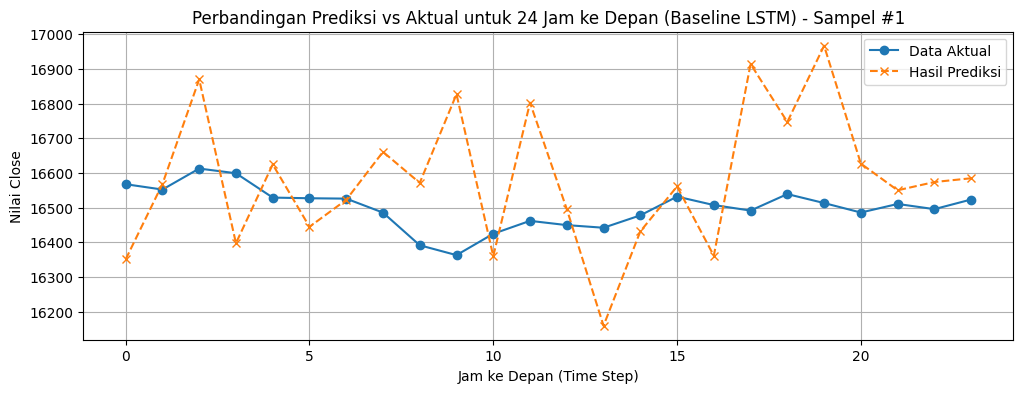

In [49]:
plt.figure(figsize=(12,4))
plt.plot(actual_24, marker="o", label="Data Aktual")
plt.plot(pred_24, marker="x", linestyle="--", label="Hasil Prediksi")
plt.title("Perbandingan Prediksi vs Aktual untuk 24 Jam ke Depan (Baseline LSTM) - Sampel #1")
plt.xlabel("Jam ke Depan (Time Step)")
plt.ylabel("Nilai Close")
plt.legend()
plt.grid(True)
plt.show()


### 12.1 Autoregressive inference untuk Seq2Seq
Membuat model encoder & decoder-step agar prediksi 24 step dilakukan secara autoregressive.

In [50]:
# Build encoder-only model
encoder_model = keras.Model(enc_in, [h, c])

# Decoder step model (1 step per iterasi)
dec_token_in = keras.Input(shape=(1,1), name="dec_token_in")
state_h_in = keras.Input(shape=(64,), name="h_in")
state_c_in = keras.Input(shape=(64,), name="c_in")

# reuse decoder LSTM + custom dense weights
dec_out_seq, h_out, c_out = dec_lstm(dec_token_in, initial_state=[state_h_in, state_c_in])
dec_token_out = layers.TimeDistributed(CustomDense(1))(dec_out_seq)

decoder_step_model = keras.Model(
    [dec_token_in, state_h_in, state_c_in],
    [dec_token_out, h_out, c_out],
)

def predict_autoregressive(x_in_batch):
    # start token = last close from input window (scaled)
    last_close = x_in_batch[:, -1:, 0:1]  # fitur ke-0 = Close (scaled)
    h0, c0 = encoder_model(x_in_batch)
    token = last_close
    outs = []
    hh, cc = h0, c0
    for _ in range(HORIZON):
        y1, hh, cc = decoder_step_model([token, hh, cc])
        outs.append(y1)
        token = y1
    return tf.concat(outs, axis=1)  # (batch, horizon, 1)

# Ambil batch test yang sama
for x_in, y_out in test_ds.take(1):
    y_true_scaled = y_out
    y_pred_scaled = predict_autoregressive(x_in)
    break

mae_seq2seq = tf.reduce_mean(tf.abs(y_true_scaled - y_pred_scaled)).numpy()
print("Seq2Seq Test MAE (scaled):", mae_seq2seq)

# inverse untuk display
y_true_inv = scalers["Close"].inverse_transform(y_true_scaled.numpy().reshape(-1,1)).reshape(-1, HORIZON)
y_pred_inv = scalers["Close"].inverse_transform(y_pred_scaled.numpy().reshape(-1,1)).reshape(-1, HORIZON)

actual_24 = y_true_inv[0]
pred_24   = y_pred_inv[0]

tabel_seq2seq = pd.DataFrame({
    "Jam ke": np.arange(1, HORIZON+1),
    "Data Aktual": actual_24,
    "Hasil Prediksi": pred_24,
    "Selisih": np.abs(actual_24 - pred_24),
})
tabel_seq2seq.head(10)


Seq2Seq Test MAE (scaled): 0.028727463


,Jam ke,Data Aktual,Hasil Prediksi,Selisih
0,1,16567.359375,16463.355469,104.003906
1,2,16551.949219,16471.451172,80.498047
2,3,16612.480469,16529.347656,83.132812
3,4,16598.949219,16606.111328,7.162109
4,5,16528.789062,16686.015625,157.226562
5,6,16526.839844,16762.009766,235.169922
6,7,16525.779297,16831.500000,305.720703
7,8,16485.449219,16893.902344,408.453125
8,9,16391.259766,16949.388672,558.128906
9,10,16362.799805,16998.343750,635.543945


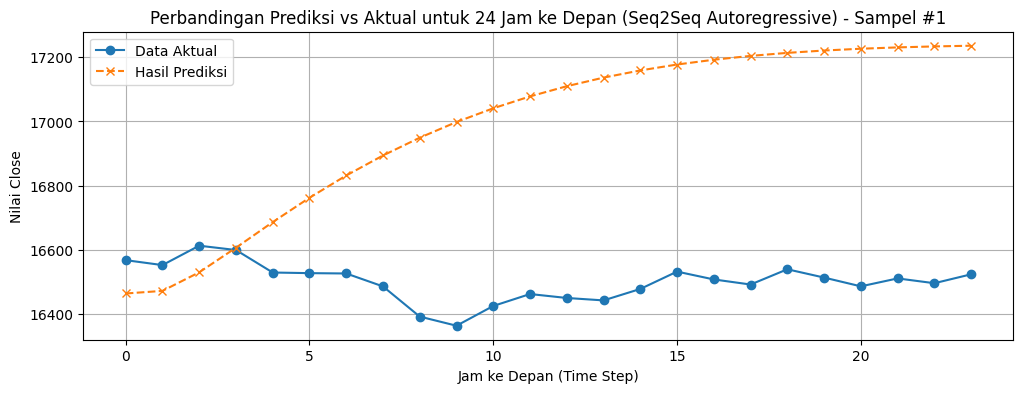

In [51]:
plt.figure(figsize=(12,4))
plt.plot(actual_24, marker="o", label="Data Aktual")
plt.plot(pred_24, marker="x", linestyle="--", label="Hasil Prediksi")
plt.title("Perbandingan Prediksi vs Aktual untuk 24 Jam ke Depan (Seq2Seq Autoregressive) - Sampel #1")
plt.xlabel("Jam ke Depan (Time Step)")
plt.ylabel("Nilai Close")
plt.legend()
plt.grid(True)
plt.show()


## 13. Catatan penting
- Pastikan notebook dijalankan sampai bawah sehingga output tersimpan.
- Pastikan file `.keras` terbuat di folder yang sama.
- Untuk target advanced, tuning hyperparameter hingga **Test MAE (scaled) < 0.015**.